# Testing panant data on ACCESS-Vis tools

In [10]:
import accessvis
import time
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import intake
import cmocean as cm
import cartopy.crs as ccrs
import xarray as xr

In [11]:
accessvis.resolution_selection(default=1)

Low-res 2K - fast for testing
Mid-res 4K - good enough for full earth views
High res 8K - better if showing close up at country scale
Ultra-high 16K - max detail but requires a fast GPU with high memory


Dropdown(description='Detail:', options=(('Low-res 2K', 1), ('Mid-res 4K', 2), ('High-res 8K', 3), ('Ultra-hig…


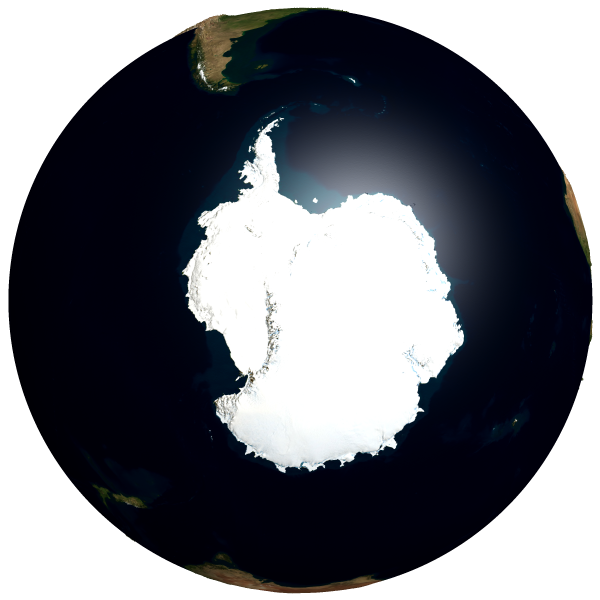

In [41]:
lv = accessvis.plot_earth(texture='bluemarble', background="white", vertical_exaggeration=20)
lv.rotation(-90.0, 0.0, -50.0) #Rotate to Antarctica
lv.translation(0.0, 0.0, -17)
lv.display(resolution=(600,600))

# Load ocean data to plot on this globe

In [14]:
filename='/g/data/x77/amh157/access-om3.mom6.2d.speed.1day.mean.1985.nc'

In [15]:
ds = xr.open_dataset(filename)

/jobfs/158838372.gadi-pbs/ipykernel_3667524/2325686122.py:1: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(filename)


In [23]:
speed=ds['speed'].isel(time=-1).load()

# Make a png file using cartopy

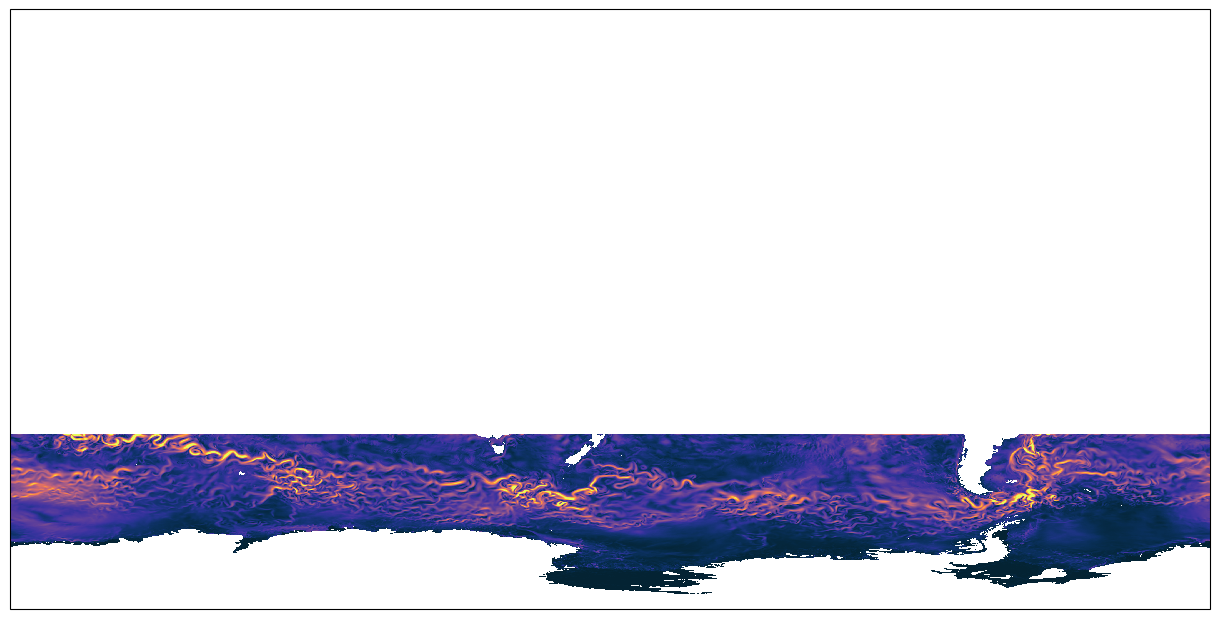

In [45]:
fig = plt.figure(figsize=(12, 6))

ax = plt.axes([0, 0, 1, 1],projection=ccrs.PlateCarree())
#ax.set_facecolor('k')

speed.plot(ax=ax,vmax=0.8,transform=ccrs.PlateCarree(central_longitude=180),cmap=cm.cm.thermal,add_colorbar=False)
plt.ylim([-90,90])
plt.title('')
plt.savefig('/g/data/x77/amh157/speed.png',dpi=300,transparent=True)

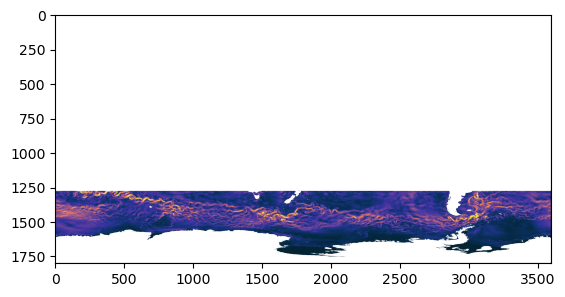

In [46]:
img = Image.open('/g/data/x77/amh157/speed.png')
arr = np.array(img)
plt.imshow(arr)


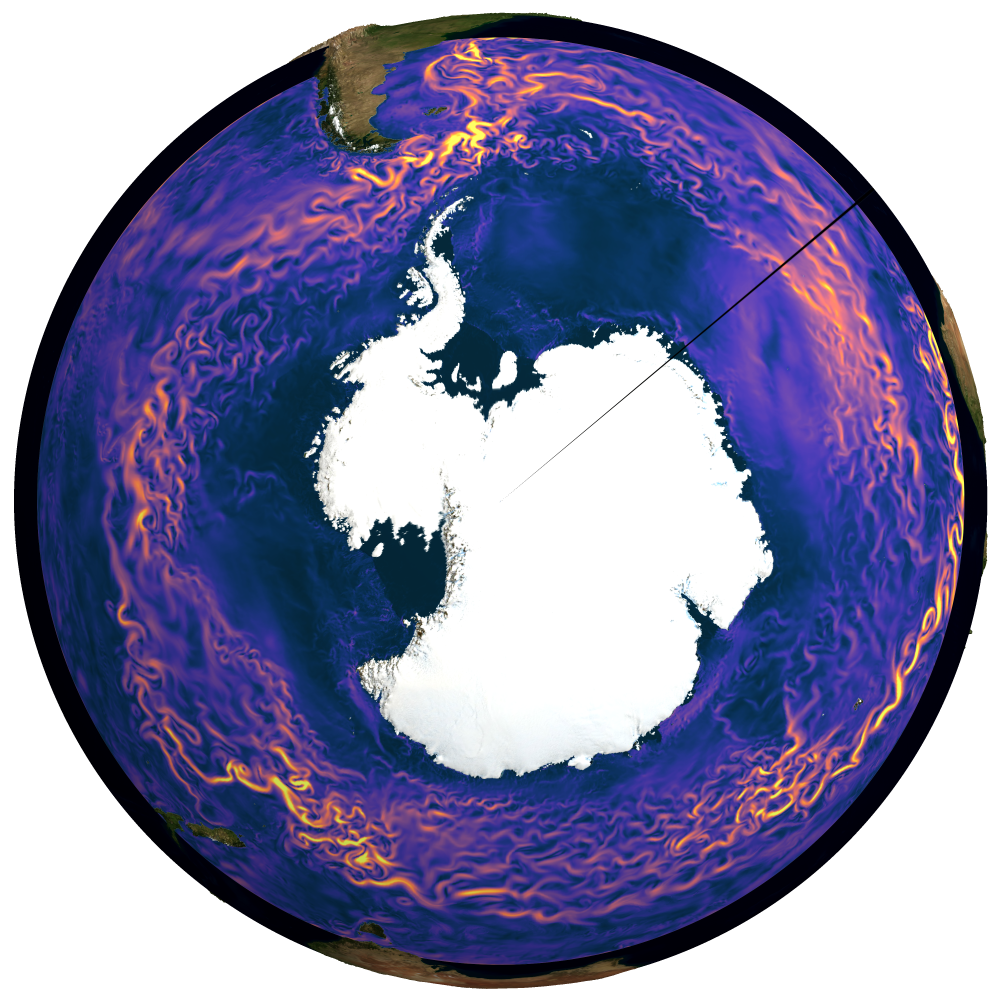

'/g/data/x77/amh157/speed-on-globe.png'

In [47]:
accessvis.update_earth_values(lv, dataMode=0, data=arr)
lv.display(resolution=(1000, 1000))
lv.image(filename='/g/data/x77/amh157/speed-on-globe.png', resolution=(1000, 1000))